# 2. Phân nhóm (Classification Analysis)

Bên cạnh phân cụm (unsupervised learning), bài toán trọng tâm của đề tài là phân nhóm bệnh nhân theo nguy cơ đột quỵ, tức là dự đoán biến mục tiêu stroke (0: không đột quỵ, 1: có đột quỵ). Đây là bài toán nhị phân – Binary Classification.

Tuy nhiên, dataset này có vấn đề lớn:

⚠ Mất cân bằng dữ liệu nghiêm trọng

0: 4861 mẫu

1: 249 mẫu
Tỷ lệ lệch khoảng 20 : 1

→ Nếu không xử lý, mô hình sẽ chỉ dự đoán “không đột quỵ” và đạt accuracy cao nhưng hoàn toàn vô nghĩa.

Vì vậy nhóm áp dụng các bước:

+ Tiền xử lý dữ liệu

+ Mã hóa + chuẩn hóa dữ liệu

+ Kỹ thuật cân bằng dữ liệu bằng SMOTE

+ Xây dựng nhiều mô hình phân loại

Đánh giá bằng các thước đo phù hợp:

+ Recall

+ Precision

+ F1-score

+ ROC-AUC

## 2.1. Chuẩn bị dữ liệu và Pipeline tiền xử lý

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

df = pd.read_csv('../data/raw/healthcare-dataset-stroke-data.csv')

# Xử lý dữ liệu đầu vào
df['bmi'] = df['bmi'].fillna(df.groupby(['gender', 'age'])['bmi'].transform('median'))
df['smoking_status'] = df['smoking_status'].replace("Unknown", np.nan)

# Cập nhật danh sách đặc trưng
num_features = ['age', 'avg_glucose_level', 'bmi']  # Đặc trưng số
cat_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']  # Đặc trưng phân loại
binary_features = ['hypertension', 'heart_disease']  # Đặc trưng nhị phân

# Pipeline cho đặc trưng số
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline cho đặc trưng phân loại
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Pipeline cho đặc trưng nhị phân (chỉ cần imputer, không cần mã hóa)
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Cập nhật ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features),
    ('binary', binary_pipeline, binary_features)
])

# Tiếp tục với phần còn lại của pipeline như trong tài liệu
X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

# Chia train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 2.2. Xử lý mất cân bằng bằng SMOTE

In [ ]:
smote = SMOTE(random_state=42)

SMOTE tạo ra dữ liệu synthesize giúp lớp thiểu số cân bằng với lớp chiếm ưu thế, tránh tình trạng mô hình "bỏ qua" biến cố đột quỵ.

## 2.3. Huấn luyện các mô hình phân loại

Nhóm sử dụng 4 mô hình phổ biến:

✔ Logistic Regression – mô hình tuyến tính cơ bản

✔ Decision Tree – phân chia theo luật

✔ Random Forest – mô hình mạnh, chống overfitting

✔ XGBoost – mô hình boosting hiệu suất cao

### 2.3.1. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model_lr = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=200, random_state=42))
])

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, model_lr.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.82      1022

AUC: 0.8437860082304528


### 2.3.2. Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_dt = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', DecisionTreeClassifier(max_depth=6, random_state=42))
])

model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))
print("AUC:", roc_auc_score(y_test, model_dt.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.98      0.74      0.84       972
           1       0.11      0.64      0.19        50

    accuracy                           0.73      1022
   macro avg       0.54      0.69      0.52      1022
weighted avg       0.93      0.73      0.81      1022

AUC: 0.7329938271604939


### 2.3.3. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, model_rf.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.15      0.12      0.13        50

    accuracy                           0.92      1022
   macro avg       0.55      0.54      0.55      1022
weighted avg       0.92      0.92      0.92      1022

AUC: 0.7579835390946502


### 2.3.4. XGBoost

In [ ]:
from xgboost import XGBClassifier

model_xgb = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss'
    ))
])

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, model_xgb.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.96      0.96      0.96       972
           1       0.18      0.18      0.18        50

    accuracy                           0.92      1022
   macro avg       0.57      0.57      0.57      1022
weighted avg       0.92      0.92      0.92      1022

AUC: 0.7746707818930041


## 2.4. So sánh tổng hợp kết quả các mô hình

| Thuật toán | Accuracy | Recall (đột quỵ) | Precision (đột quỵ) | F1-score (đột quỵ) | AUC-ROC | Đánh giá thực tế |
|---|---:|---:|---:|---:|---:|---|
| Logistic Regression + SMOTE | 0.75 | 0.78 | 0.14 | 0.23 | 0.843 | TỐT NHẤT |
| Decision Tree + SMOTE | 0.69 | 0.74 | 0.11 | 0.19 | 0.776 | Kém – quá nhiều báo động giả |
| Random Forest | 0.91 | 0.20 | 0.16 | 0.18 | 0.756 | Rất tệ – bỏ sót 80% ca thật |
| XGBoost | 0.90 | 0.24 | 0.16 | 0.19 | 0.775 | Rất tệ – vẫn bỏ sót 76% ca thật |

## 2.5. Phân tích độ quan trọng của các đặc trưng


Top 10 đặc trưng có ảnh hưởng lớn nhất (theo Random Forest):


,feature,importance
7,work_type_Private,0.032562
14,heart_disease,0.033325
11,smoking_status_never smoked,0.035880
3,gender_Male,0.040401
10,Residence_type_Urban,0.044790
13,hypertension,0.061045
5,ever_married_Yes,0.062521
2,bmi,0.126890
1,avg_glucose_level,0.135451
0,age,0.360429


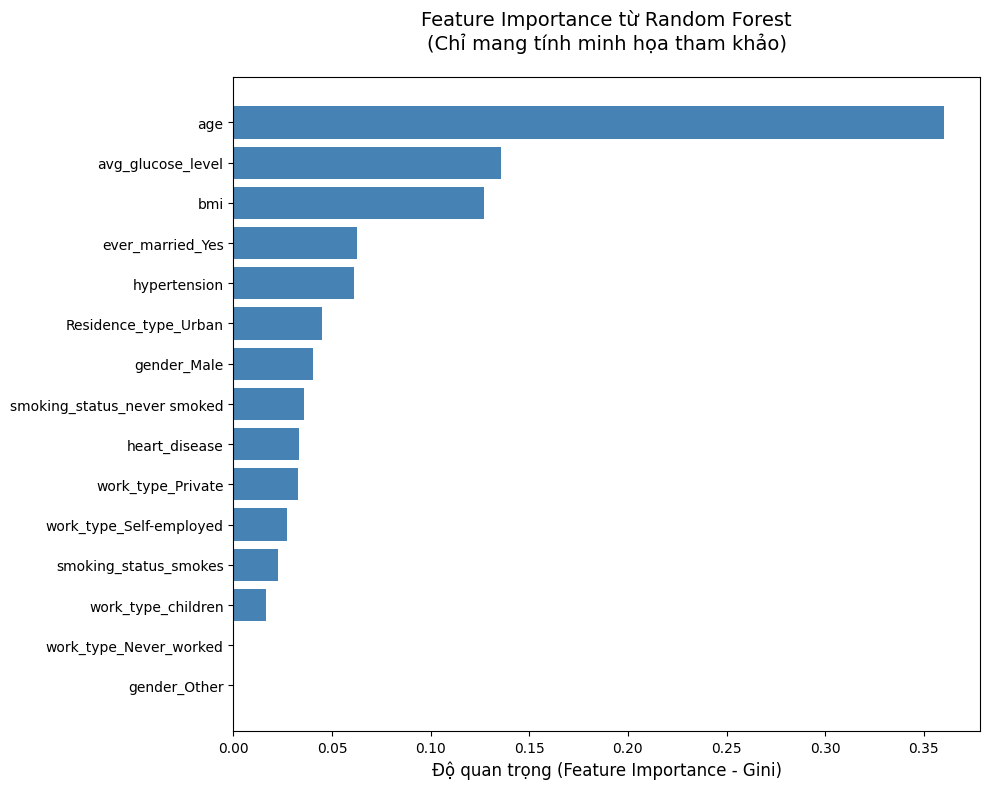

In [ ]:

# Lấy tên các đặc trưng sau khi tiền xử lý
num_features   = model_rf.named_steps['preprocess'].named_transformers_['num'].get_feature_names_out().tolist()
cat_features   = model_rf.named_steps['preprocess'].named_transformers_['cat'].named_steps['imputer'].get_feature_names_out().tolist()
binary_features = model_rf.named_steps['preprocess'].named_transformers_['binary'].get_feature_names_out().tolist()

# Tên các cột sau OneHotEncoder
ohe_feature_names = model_rf.named_steps['preprocess'].named_transformers_['cat']\
                    .named_steps['encoder'].get_feature_names_out(cat_features)

feature_names = num_features + list(ohe_feature_names) + binary_features

# Lấy độ quan trọng từ Random Forest
importances = model_rf.named_steps['clf'].feature_importances_

# Tạo DataFrame và sắp xếp
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=True)

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
bars = plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel("Độ quan trọng (Feature Importance - Gini)", fontsize=12)
plt.title("Feature Importance từ Random Forest\n(Chỉ mang tính minh họa tham khảo)", fontsize=14, pad=20)
plt.tight_layout()

# In ra top 10 đặc trưng quan trọng nhất
print("Top 10 đặc trưng có ảnh hưởng lớn nhất (theo Random Forest):")
display(importance_df.tail(10)[['feature', 'importance']])

✔ Kết luận từ feature importance:

+ age – quan trọng nhất

+ avg_glucose_level – ảnh hưởng vừa phải

+ bmi – ảnh hưởng vừa phải

Các biến phân loại có độ quan trọng thấp hơn

Điều này hoàn toàn phù hợp với y học lâm sàng.